# Data Analysis SaaS Amazon
*Oleh: Darrell Lokadeva Lim*

## Latar Belakang
Amazon, sebagai perusahaan teknologi yang menyediakan layanan *Software as a Service* (SaaS), memiliki basis data penjualan berskala global. Dalam upaya mempertahankan keberlanjutan bisnis dan pertumbuhan perusahaan, Amazon harus memastikan bahwa tingkat profitabilitas secara keseluruhan tetap positif. Salah satu strategi pemasaran dan penjualan yang sering diterapkan oleh perusahaan adalah dengan memberikan diskon. Namun, strategi pemberian diskon ini seringkali menjadi pisau bermata dua; di satu sisi dapat menaikkan volume penjualan, namun di sisi lain berisiko menggerus profit jika tidak dilakukan dengan tepat.

## Pernyataan Masalah
Perusahaan menemukan beberapa anomali saat melakukan pengulikan data, di mana beberapa transaksi diberi diskon justru malah merugi. Selain itu, perusahaan masih belum mengetahui seberapa parah tingkat diskon tersebut sehingga bisa merusak keuntungan perusahaan. Oleh karena itu, perusahaan sedang mencari tahu **seberapa besar pengaruh pemeberian diskon terhadap profitabilitas**.

## Tujuan Analisis
Sebagai seorang *data analyst*, kita akan melakukan analisis untuk menjawab:
- **Bagaimana dampak pemberian diskon terhadap profit?**
- **Jika berdampak, produk atau segmen pelanggan mana saja yang paling memicu kerugian bagi perusahaan?**

## Manfaat bagi Stakeholders
Informasi dan *insight* dari hasil analisis ini akan sangat bermanfaat bagi pihak manajemen, *sales*, dan *marketing* terkait pembuat keputusan untuk:
- **Merumuskan ulang kebijakan diskon:** Mengetahui batas aman pemberian diskon yang tidak mengorbankan margin.
- **Mengoptimalkan strategi penetapan harga (*pricing*):** Menyesuaikan kembali harga dan pendekatan pemasaran khusus untuk segmen atau produk yang paling rentan merugi.
- **Mencegah kebocoran finansial di masa depan:** Membantu menekan angka transaksi yang merugi agar tingkat profitabilitas perusahaan secara keseluruhan kembali sehat dan terus bertumbuh.


## Data
Untuk menjawab pertanyaan di atas, kita akan mulai menganalisa data transaksi yang sudah dikumpulkan perusahaan. Dataset dapat diakses menggunakan [link ini](https://www.kaggle.com/datasets/nnthanh101/aws-saas-sales).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy.stats import normaltest, spearmanr, mannwhitneyu

# Mengatur opsi tampilan untuk menampilkan semua kolom
pd.set_option('display.max_seq_items', None)

Dataset ini berisi data transaksi dari sebuah perusahaan SaaS fiktif (AWS) yang menjual perangkat lunak (software) penjualan dan pemasaran kepada perusahaan lain (B2B). Di dalam dataset ini, setiap baris merepresentasikan suatu produk dalam sebuah transaksi, dan kolom-kolomnya meliputi:

1. Row ID: ID unik untuk setiap transaksi.
2. Order ID: ID unik untuk setiap pesanan.
3. Order Date: Tanggal ketika pesanan dibuat.
4. Date Key: Representasi numerik dari tanggal pesanan (YYYYMMDD).
5. Contact Name: Nama orang yang melakukan pemesanan.
6. Country: Negara tempat pesanan dilakukan.
7. City: Kota tempat pesanan dilakukan.
8. Region: Wilayah (region) tempat pesanan dilakukan.
9. Subregion: Sub-wilayah (subregion) tempat pesanan dilakukan.
10. Customer: Nama perusahaan yang melakukan pemesanan.
11. Customer ID: ID unik untuk setiap pelanggan.
12. Industry: Sektor industri dari pelanggan.
13. Segment: Segmen pelanggan (SMB, Strategic, Enterprise, dll.).
14. Product: Produk yang dipesan.
15. License: Kunci lisensi untuk produk tersebut.
16. Sales: Total nilai penjualan untuk transaksi tersebut.
17. Quantity: Total jumlah barang/item dalam transaksi.
18. Discount: Diskon yang diberikan atau diterapkan pada transaksi.
19. Profit: Keuntungan (profit) yang didapatkan dari transaksi.

Berikut adalah 5 baris teratas dan terbawah dari dataset `SaaS-Sales.csv`.

In [6]:
df = pd.read_csv('SaaS-Sales.csv')
print("Head:")
df.head()

Head:


,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164


In [7]:
print("Tail:")
df.tail()

Tail:


,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
9989,9990,EMEA-2020-110422,1/22/2020,20200122,Dan Allan,Germany,Hamburg,EMEA,EU-WEST,Johnson & Johnson,1055,Healthcare,SMB,SaaS Connector Pack,ETHXMB5TMD,25.248,3,0.2,4.1028
9990,9991,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,SaaS Connector Pack,LYHOKTRY7L,91.960,2,0.0,15.6332
9991,9992,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Site Analytics,I5SVMI6M88,258.576,2,0.2,19.3932
9992,9993,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Support,JHLW4P6LQ2,29.600,4,0.0,13.3200
9993,9994,AMER-2023-119914,5/5/2023,20230505,Jasmine Springer,United States,Dallas,AMER,NAMER,Comcast,1022,Communications,SMB,OneView,3NTBV9B3PS,243.160,2,0.0,72.9480


## Data Understanding dan Cleaning

Sebelum masuk ke dalam tahap analisis yang lebih mendalam, kita perlu mengenali dataset yang kita miliki lebih jauh melalui proses *data understanding*. Dari proses ini, kita dapat mengidentifikasi karakteristik data, mendeteksi anomali, melihat jumlah data kosong (*missing values*), data duplikat, hingga tipe data yang kurang tepat.

Setelah mengetahui kondisi data, anomali dan ketidaksesuaian tersebut akan kita perbaiki dalam tahapan *data cleaning*. Setiap langkah pembersihan (seperti penyesuaian tipe data dan standardisasi format) dilakukan agar data menjadi valid dan dapat diandalkan (*reliable*) untuk menghasilkan *insight* bisnis yang akurat.

Pertama, mari kita cek informasi umum, tipe data, serta statistik deskriptif dari dataset transaksi tersebut.

In [9]:
print(f"Jumlah baris dan kolom: {df.shape}\n")
df.info()

Jumlah baris dan kolom: (9994, 19)

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   str    
 2   Order Date    9994 non-null   str    
 3   Date Key      9994 non-null   int64  
 4   Contact Name  9994 non-null   str    
 5   Country       9994 non-null   str    
 6   City          9994 non-null   str    
 7   Region        9994 non-null   str    
 8   Subregion     9994 non-null   str    
 9   Customer      9994 non-null   str    
 10  Customer ID   9994 non-null   int64  
 11  Industry      9994 non-null   str    
 12  Segment       9994 non-null   str    
 13  Product       9994 non-null   str    
 14  License       9994 non-null   str    
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Pro

In [10]:
df[['Sales', 'Quantity','Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [11]:
df.describe(include='object')

/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_1523/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Industry,Segment,Product,License
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,793,48,262,3,12,99,10,3,14,9994
top,EMEA-2023-100111,9/6/2022,Leonard Kelly,United States,London,EMEA,NAMER,Allianz,Finance,SMB,ContactMatcher,16GRM07R1K
freq,14,38,37,2001,922,4219,2507,192,2127,5191,1842,1


In [12]:
columns = df.columns
dtype = df.dtypes
total_unique = [df[col].nunique() for col in df.columns]
unique = [df[col].unique() for col in df.columns]

description = pd.DataFrame({
    'type': dtype,
    'total_unique': total_unique,
    'unique': unique
})

description

,type,total_unique,unique
Row ID,int64,9994,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
Order ID,str,5009,"[EMEA-2022-152156, AMER-2022-138688, EMEA-2021..."
Order Date,str,1237,"[11/9/2022, 6/13/2022, 10/11/2021, 6/9/2020, 4..."
Date Key,int64,1237,"[20221109, 20220613, 20211011, 20200609, 20230..."
Contact Name,str,793,"[Nathan Bell, Deirdre Bailey, Zoe Hodges, Thom..."
Country,str,48,"[Ireland, United States, Germany, Sweden, Cana..."
City,str,262,"[Dublin, New York City, Stuttgart, Stockholm, ..."
Region,str,3,"[EMEA, AMER, APJ]"
Subregion,str,12,"[UKIR, NAMER, EU-WEST, NOR, JAPN, EU, MEA, LAT..."
Customer,str,99,"[Chevron, Phillips 66, Royal Dutch Shell, BNP ..."


Setelah melakukan *breakdown* dan pengecekan awal, diketahui bahwa:
- Dataset `SaaS-Sales.csv` memiliki 9.994 baris dan 19 kolom.
- Secara keseluruhan, **tidak terdapat *missing value*** (0%) atau data kosong pada semua kolom dataset.
- Kolom `Order Date` masih dibaca sebagai string (`object`) dan perlu diubah ke format tanggal (`datetime`) untuk mempermudah analisis berdasarkan tren waktu.
- Kolom seperti `Customer ID` dan `Segment` saat ini memiliki tipe data string (`object`), yang sudah sesuai secara umum, namun bisa dipastikan lebih lanjut keseragaman formatnya.
- Pada statistik deskriptif, terlihat nilai minimum `Profit` adalah negatif (mencapai batas kerugian hingga -6599.98). Ini mengonfirmasi pernyataan masalah kita bahwa ada transaksi yang merugikan. 
- Kita juga perlu mengecek lebih lanjut di tahap berikutnya apakah terdapat duplikasi data atau inkonsistensi penamaan/kategorisasi pada data-data kategorikal (seperti wilayah dan jenis produk).

Dari temuan masalah tipe data awal ini, kita akan melakukan penyesuaian serta pendalaman anomali pada tahapan **Data Cleaning** di bawah ini agar dataset siap dan lebih akurat untuk dianalisis.

# Data Cleaning

Walaupun tidak ada *missing value*, kita menyarankan untuk memeriksa lagi terlebih dahulu supaya mengkonfirmasi bahwa dataset benar-benar tidak memiliki data kosong. 

In [32]:
# Banyaknya dan persentase missing values
missing_values_count = df.isnull().sum()
missing_values_percentage = (missing_values_count / len(df)) * 100

missing_values_df = pd.DataFrame({
    'missing_values_count': missing_values_count,
    'missing_values_percentage': missing_values_percentage
})

missing_values_df

,missing_values_count,missing_values_percentage
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Date Key,0,0.0
Contact Name,0,0.0
Country,0,0.0
City,0,0.0
Region,0,0.0
Subregion,0,0.0
Customer,0,0.0


<Axes: >

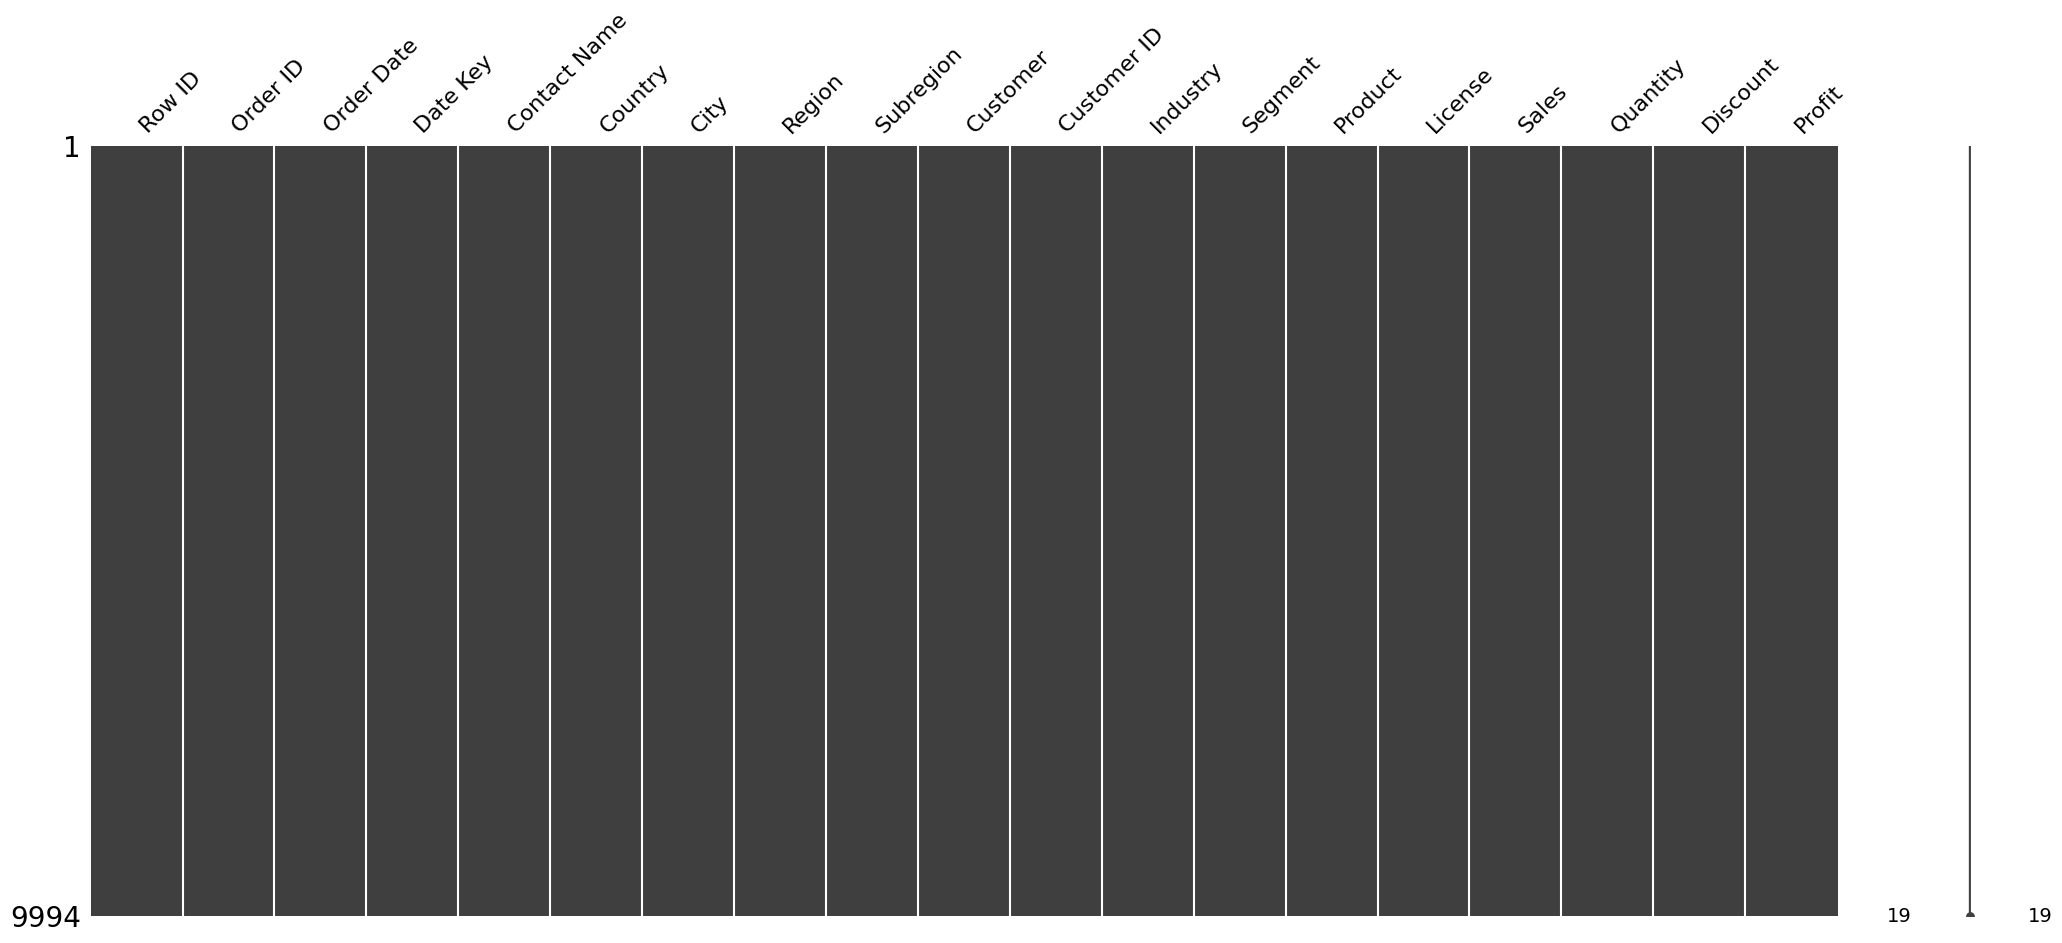

In [33]:
msno.matrix(df)

Diketahui bahwa dataset ini benar-benar tidak memiliki missing value, sehingga semua kolom bisa digunakan untuk keperluan analisis. Selanjutnya kita akan melakukan penyesuaian tipe data untuk kolom-kolom berikut: (jelasin kenapa diubah)
1. Ganti `Order Date` jadi `datetime` format
> Sebelumnya, kolom ini terbaca sebagai teks biasa (`object`). Mengubahnya ke dalam format *datetime* akan sangat memudahkan kita jika nantinya perlu melakukan analisis berbasis waktu (*time-series*), mengurutkan data secara kronologis, atau mengambil komponen spesifik seperti bulan dan tahun transaksi.
2. Ganti `Customer ID` dan `Date Key` jadi `str` format
> Walaupun kolom-kolom ini berisi angka, nilai di dalamnya berfungsi sebagai kode kategorikal, bukan sebagai angka yang memiliki nilai matematis. Mengubahnya menjadi teks (*string*) berfungsi untuk mencegah terjadinya perhitungan statistik yang tidak disengaja.

In [34]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Customer ID'] = df['Customer ID'].astype(str)
df['Segment'] = df['Segment'].astype(str)

Setelah melakukan penyesuaian data, kita akan melakukan penyesuaian `Region` dan `Subregion` dalam dataset tersebut. 
> Alasan mengapa kita melakukan penyesuaian `Region` dan `subregion` adalah terdapat beberapa region/subregion yang menurut kita tidak terlalu cocok atau salah.

In [35]:
print("Unique values in 'Region':", df['Region'].unique())
for region in df['Region'].unique():
    print(f"Unique values in 'Subregion' for {region}: {df[df['Region'] == region]['Subregion'].unique()}")

print("\nFor every subregion:")
for subregion in df['Subregion'].unique():
    print(f"Unique values in 'Country' for {subregion}: {df[df['Subregion'] == subregion]['Country'].unique()}")

Unique values in 'Region': <StringArray>
['EMEA', 'AMER', 'APJ']
Length: 3, dtype: str
Unique values in 'Subregion' for EMEA: <StringArray>
['EU-UKIR', 'EU-WEST', 'EU-NORTH', 'EU-SOUTH', 'MEA', 'RUS', 'EU-EAST']
Length: 7, dtype: str
Unique values in 'Subregion' for AMER: <StringArray>
['NAMER', 'LATAM']
Length: 2, dtype: str
Unique values in 'Subregion' for APJ: <StringArray>
['JPN', 'ANZ', 'ASEAN', 'SA', 'KOR', 'CHI']
Length: 6, dtype: str

For every subregion:
Unique values in 'Country' for EU-UKIR: <StringArray>
['Ireland', 'United Kingdom']
Length: 2, dtype: str
Unique values in 'Country' for NAMER: <StringArray>
['United States', 'Canada']
Length: 2, dtype: str
Unique values in 'Country' for EU-WEST: <StringArray>
['Germany', 'France', 'Luxembourg', 'Belgium', 'Netherlands', 'Austria']
Length: 6, dtype: str
Unique values in 'Country' for EU-NORTH: <StringArray>
['Sweden', 'Finland', 'Norway', 'Denmark', 'Iceland']
Length: 5, dtype: str
Unique values in 'Country' for JPN: <StringA

Setelah dianalisis, ternyata terjadi beberapa kesalahan dalam penempatan negara di setiap `Subregion`, seperti:
- Negara-negara Eropa hanya terbagi dalam 3 bagian (EU-WEST, EU, EU-EAST).
- `Subregion` NOR memiliki konteks yang tidak terlalu jelas (apakah itu Northern Europe, Norway, atau apa?) 
- Israel, negara yang berada di Timur Tengah (Middle East), ditempatkan di `Subregion` EU-EAST.
- APAC seharusnya bisa dijadikan satu dengan ANZ dan JAPN karena berada di kawasan yang sama, tapi sebaiknya APAC dipecah lagi menjadi kawasan-kawasan yang lebih kecil. 

Sekarang, kita akan mulai menempatkan negara-negara tersebut ke `Subregion` yang tepat.

In [36]:
eu_west = ['Germany', 'France', 'Netherlands', 'Belgium', 'Austria', 'Switzerland']
eu_east = ['Poland', 'Czech Republic', 'Hungary', 'Romania', 'Slovakia', 'Slovenia', 'Croatia', 'Bulgaria', 'Lithuania', 'Latvia', 'Estonia']
eu_north = ['Sweden', 'Norway', 'Denmark', 'Finland', 'Iceland']
eu_south = ['Italy', 'Spain', 'Greece', 'Portugal']
eu_ukir = ['United Kingdom', 'Ireland']
russia = ['Russia', 'Ukraine', 'Belarus', 'Georgia', 'Azerbaijan', 'Armenia']

df.loc[df['Country'].isin(eu_west), 'Subregion'] = 'EU-WEST'
df.loc[df['Country'].isin(eu_east), 'Subregion'] = 'EU-EAST'
df.loc[df['Country'].isin(eu_north), 'Subregion'] = 'EU-NORTH'
df.loc[df['Country'].isin(eu_south), 'Subregion'] = 'EU-SOUTH'
df.loc[df['Country'].isin(eu_ukir), 'Subregion'] = 'EU-UKIR'
df.loc[df['Country'].isin(russia), 'Subregion'] = 'RUS'

df.loc[df['Country'].isin(['Israel']), 'Subregion'] = 'MEA'

apj_anz = ['Australia', 'New Zealand']
apj_japan = ['Japan']
apj_china = ['China', 'Hong Kong', 'Taiwan']
apj_asean = ['Singapore', 'Indonesia', 'Malaysia', 'Thailand', 'Philippines', 'Vietnam']
apj_india = ['India', 'Sri Lanka', 'Bangladesh']
apj_korea = ['South Korea']

df.loc[df['Country'].isin(apj_anz), 'Subregion'] = 'ANZ'
df.loc[df['Country'].isin(apj_japan), 'Subregion'] = 'JPN'
df.loc[df['Country'].isin(apj_china), 'Subregion'] = 'CHI'
df.loc[df['Country'].isin(apj_asean), 'Subregion'] = 'ASEAN'
df.loc[df['Country'].isin(apj_india), 'Subregion'] = 'SA'
df.loc[df['Country'].isin(apj_korea), 'Subregion'] = 'KOR'

Kita telah berhasil mengatur negara-negara ke subregion yang tepat, mari kita sekilas lihat informasi dari data yang sudah dirapihkan.

In [37]:
print("Unique values in 'Region':", df['Region'].unique())
for region in df['Region'].unique():
    print(f"Unique values in 'Subregion' for {region}: {df[df['Region'] == region]['Subregion'].unique()}")

print("\nFor every subregion:")
for subregion in df['Subregion'].unique():
    print(f"Unique values in 'Country' for {subregion}: {df[df['Subregion'] == subregion]['Country'].unique()}")


Unique values in 'Region': <StringArray>
['EMEA', 'AMER', 'APJ']
Length: 3, dtype: str
Unique values in 'Subregion' for EMEA: <StringArray>
['EU-UKIR', 'EU-WEST', 'EU-NORTH', 'EU-SOUTH', 'MEA', 'RUS', 'EU-EAST']
Length: 7, dtype: str
Unique values in 'Subregion' for AMER: <StringArray>
['NAMER', 'LATAM']
Length: 2, dtype: str
Unique values in 'Subregion' for APJ: <StringArray>
['JPN', 'ANZ', 'ASEAN', 'SA', 'KOR', 'CHI']
Length: 6, dtype: str

For every subregion:
Unique values in 'Country' for EU-UKIR: <StringArray>
['Ireland', 'United Kingdom']
Length: 2, dtype: str
Unique values in 'Country' for NAMER: <StringArray>
['United States', 'Canada']
Length: 2, dtype: str
Unique values in 'Country' for EU-WEST: <StringArray>
['Germany', 'France', 'Luxembourg', 'Belgium', 'Netherlands', 'Austria']
Length: 6, dtype: str
Unique values in 'Country' for EU-NORTH: <StringArray>
['Sweden', 'Finland', 'Norway', 'Denmark', 'Iceland']
Length: 5, dtype: str
Unique values in 'Country' for JPN: <StringA

Duplikasi data juga sangat penting untuk diperiksa. Sebelum itu, marilah kita memeriksa jika dataset memiliki data duplikat.

In [38]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}")
df[df.duplicated(keep=False)]

Jumlah data duplikat: 0


,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit


Mantap! Dataset ini sepertinya sudah dicleaning dari awal, sehingga tidak terdapat data duplikat.

## Data Analysis
Kita sudah melakukan tahap data cleaning. Selanjutnya, kita akan mulai melakukan analisis untuk mencari tahu **bagaimana dampak pemberian diskon terhadap profit, dan produk atau segmen pelanggan mana saja yang paling memicu kerugian**.

Pertama-tama, kita akan mengekstrak informasi mengenai nilai di bawah nol (negatif) pada dataset. Hal ini bertujuan untuk mengkonfirmasi jumlah transaksi yang mengalami kerugian, seperti `Profit < 0`, sekaligus memastikan tidak ada anomali pada kolom transaksi lainnya.

In [39]:
discount_below_zero = len(df[df['Discount'] < 0])
quantity_below_zero = len(df[df['Quantity'] < 0])
sales_below_zero = len(df[df['Sales'] < 0])
profit_below_zero = len(df[df['Profit'] < 0])

below_zero = pd.DataFrame({
    'Column': ['Discount', 'Quantity', 'Sales', 'Profit'],
    'Below Zero Amount': [discount_below_zero, quantity_below_zero, sales_below_zero, profit_below_zero]
})

below_zero

,Column,Below Zero Amount
0,Discount,0
1,Quantity,0
2,Sales,0
3,Profit,1871


Dari tabel di atas, kita dapat mengonfirmasi bahwa terdapat 1.871 transaksi yang mengalami kerugian. Data pada `Sales`, `Quantity`, dan `Discount` bernilai wajar (tidak ada yang negatif). 

Selanjutnya, kita akan mengfilter *dataframe* khusus untuk transaksi yang merugi (`Profit < 0`) dan mengelompokkannya berdasarkan besaran diskon untuk melihat mana yang memiliki frekuensi dan total kerugian paling besar.

In [40]:
profit_loss = df[df['Profit'] < 0]
summary_disc_lost = profit_loss.groupby('Discount').agg(
    Total_Loss=('Profit', 'sum'),
    Count_Loss=('Order ID', 'count')
).reset_index()

summary_disc_lost.sort_values(by='Total_Loss', ascending=True)

,Discount,Total_Loss,Count_Loss
9,0.70,-40075.3569,418
10,0.80,-30539.0392,300
5,0.40,-25787.8268,180
7,0.50,-20506.4281,66
2,0.20,-17258.0654,502
3,0.30,-10777.6879,208
8,0.60,-5944.6552,138
6,0.45,-2493.1111,11
4,0.32,-2391.1377,27
1,0.15,-328.7030,17


Tabel di atas menunjukkan bahwa kerugian terbesar banyak terdistribusi pada tingkat diskon tertentu (misal: diskon 0.7, 0.4, 0.5).

Untuk membuktikan secara statistik apakah diskon memang memberikan dampak yang signifikan terhadap keuntungan perusahaan, kita akan merumuskan **Uji Hipotesis**, dimana kita bertanya **apakah ada perbedaan rata-rata/median Profit yang signifikan antara transaksi yang diberikan diskon dengan yang tidak diberikan diskon?**. 

Langkah pertama adalah **Uji Normalitas**. Karena ukuran data kita cukup besar (>5000 baris), kita menggunakan *D'Agostino's K-squared test* untuk melihat apakah distribusi `Profit` pada transaksi berdiskon dan tanpa diskon berdistribusi normal, sebelum memilih alat uji parametrik atau non-parametrik.
>Mengapa kita perlu menguji normalitas pada kedua kelompok ini secara terpisah? Karena jika salah satu atau kedua kelompok tidak berdistribusi normal, kita tidak bisa menggunakan uji parametrik (seperti *T-Test*) dan harus beralih ke uji non-parametrik agar hasil analisis tetap valid/tidak bias.
 

In [41]:
profit_no_discount = df[df['Discount'] == 0]['Profit']
profit_with_discount = df[df['Discount'] > 0]['Profit']

stat_no, p_val_no = normaltest(profit_no_discount)
stat_with, p_val_with = normaltest(profit_with_discount)

print(f"Tanpa diskon - Stats: {stat_no}, P-value: {p_val_no}")
print(f"Dengan diskon - Stats: {stat_with}, P-value: {p_val_with}")

if p_val_no < 0.05 or p_val_with < 0.05:
    print("\nTolak H0: Data tidak berdistribusi normal. Gunakan uji non-parametrik.")
else:
    print("\nGagal menolak H0: Data berdistribusi normal. Gunakan uji parametrik.")

Tanpa diskon - Stats: 9892.948370825256, P-value: 0.0
Dengan diskon - Stats: 8444.807129621706, P-value: 0.0

Tolak H0: Data tidak berdistribusi normal. Gunakan uji non-parametrik.


Setelah dianalisis, ternyata kedua kelompok tersebut memiliki distribusi yang tidak normal, alias *skewed* (Profit tanpa diskon memiliki p-value 0.0, profit dengan diskon memiliki p-value 0.0). Untuk menambahkan bukti, kita menambahkan visualisasi histogram dan boxplot. 

Text(0.5, 1.0, 'Distribusi Profit Tanpa Diskon')

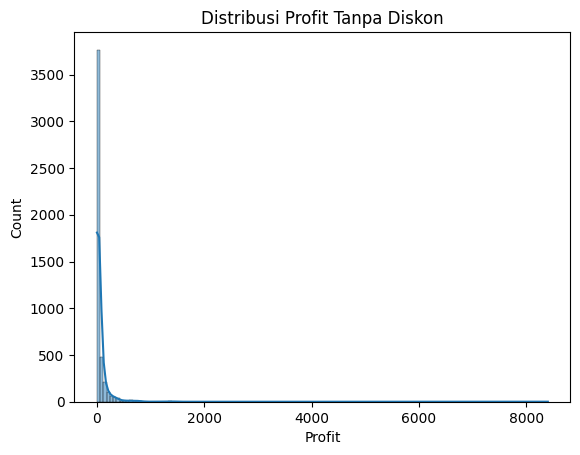

In [42]:
# Justification 1
sns.histplot(profit_no_discount, kde=True, label='Tanpa Diskon')
plt.title('Distribusi Profit Tanpa Diskon')

Text(0.5, 1.0, 'Distribusi Profit Dengan Diskon')

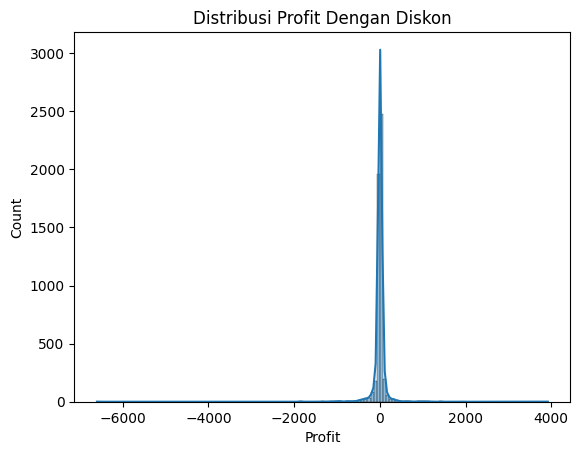

In [43]:
# Justification 2
sns.histplot(profit_with_discount, kde=True, label='Dengan Diskon')
plt.title('Distribusi Profit Dengan Diskon')

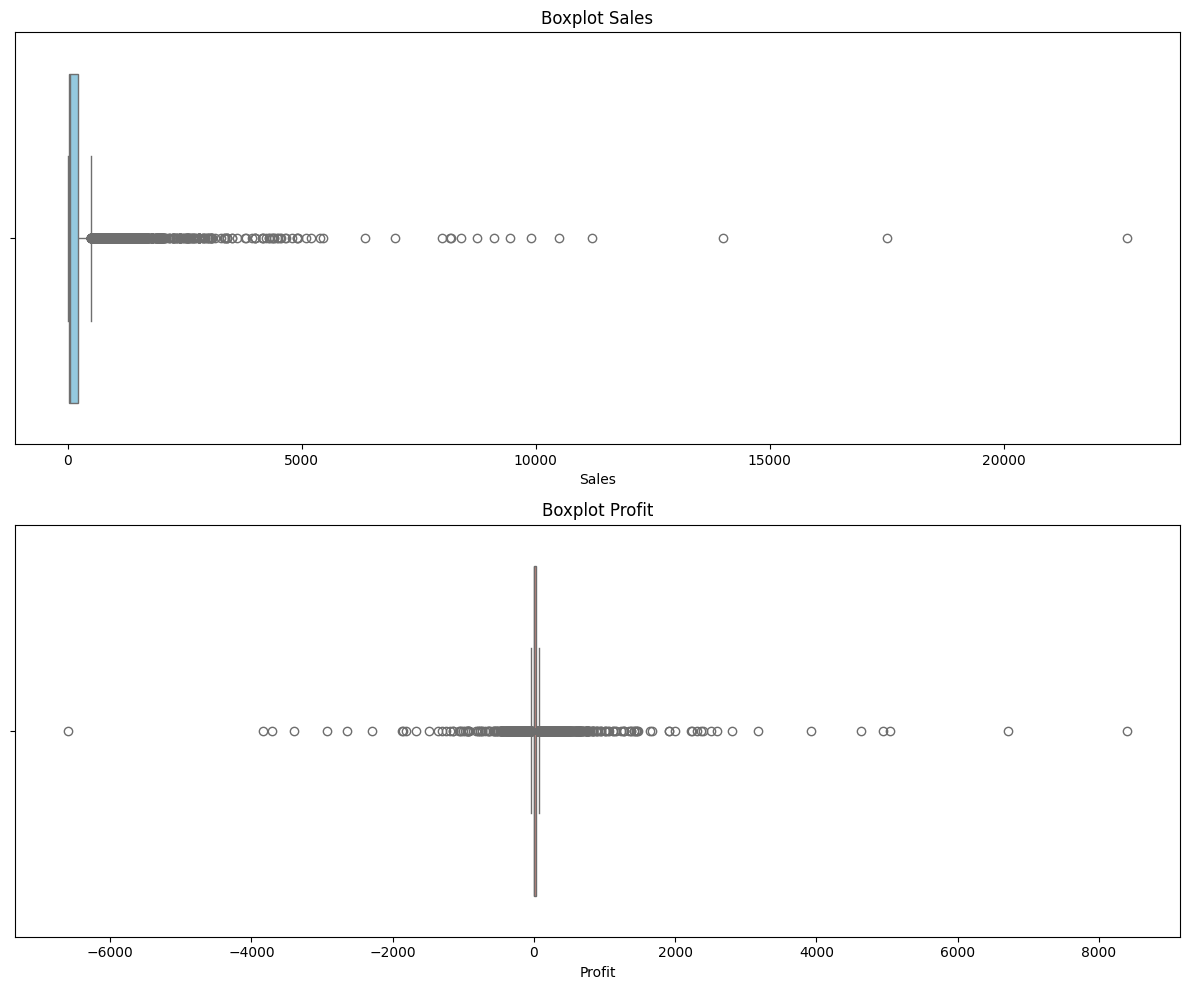

In [44]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
sns.boxplot(data=df, x='Sales', ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot Sales')

sns.boxplot(data=df, x='Profit', ax=axes[1], color='salmon')
axes[1].set_title('Boxplot Profit')
plt.tight_layout()
plt.show()

Setelah divisualisasi, hasil histogram menunjukkan distribusi data yang sangat *skewed* (tidak berdistribusi normal), dimana distribusi "Profit Tanpa Diskon" memiliki distribusi *right-skewed* dan distribusi "Profit Tanpa Diskon" memiliki distribusi *left-skewed*. Selain itu, *boxplot* mengkonfirmasi banyaknya *outliers* ekstrim, namun tetap kita pertahankan karena ini adalah bagian dari realita bisnis perusahaan. 

Mengingat data tidak terdistribusi normal, hipotesis awal akan kita uji menggunakan **Uji Non-Parametrik (Mann-Whitney U Test)** untuk melihat adakan perbedaan median/distribusi Profit secara signifikan antara yang didiskon vs tanpa diskon.

In [45]:
stat, p_value = mannwhitneyu(profit_no_discount, profit_with_discount, alternative='two-sided')
print(f"Mann-Whitney U Test - Stat: {stat}, P-value: {p_value}")

if p_value < 0.05:
    print("\nTolak H0: Ada cukup bukti bahwa terdapat perbedaan signifikan dalam profit antara transaksi dengan diskon dan tanpa diskon.")
else:
    print("\nGagal menolak H0: Tidak ada cukup bukti bahwa terdapat perbedaan signifikan dalam profit antara transaksi dengan diskon dan tanpa diskon.")

Mann-Whitney U Test - Stat: 18663602.5, P-value: 0.0

Tolak H0: Ada cukup bukti bahwa terdapat perbedaan signifikan dalam profit antara transaksi dengan diskon dan tanpa diskon.


Setelah pengujian, ternyata uji Mann-Whitney U-Test mengindikasikan adanya efek *impact* yang jelas antara pemberian diskon dengan profit. Namun, seberapa erat dan berbanding terbalik-kah hubungan antara besaran diskon itu sendiri dengan besaran keuntungan? Kita akan mengukurnya menggunakan **Spearman Correlation Test** (karena asumsi normalitas tidak terpenuhi).

In [46]:
correlation_matrix = df[['Discount', 'Profit']].corr(method='spearman')
correlation_value, p_value = spearmanr(df['Discount'], df['Profit'])

print(f"Spearman Correlation: {correlation_value}, P-value: {p_value}")
print("\nInterpretasi:")
if p_value < 0.05:
    print("Tolak H0: Terdapat korelasi yang signifikan antara diskon dan profit.")
else:
    print("Terima H0: Tidak terdapat korelasi yang signifikan antara diskon dan profit.")

Spearman Correlation: -0.5433501822306213, P-value: 0.0

Interpretasi:
Tolak H0: Terdapat korelasi yang signifikan antara diskon dan profit.


Dari hasil korelasi Spearman, didapati korelasi negatif yang signifikan, yang artinya **semakin besar diskon yang diberikan, secara statistik profit memang cenderung semakin anjlok**.

Untuk memahami lebih lanjut batas aman pemberian diskon, kita akan memvisualisasikan rata-rata keuntungan (*Profit*) pada setiap instrumen persentase diskon. Kita juga akan menelusuri bagaimana distribusi total kerugian tersebut jika dibedah berdasarkan **Segmen** pasarnya.

/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_1523/1355673901.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Discount', y='Profit', errorbar=None, palette='Reds_r', estimator=np.mean)


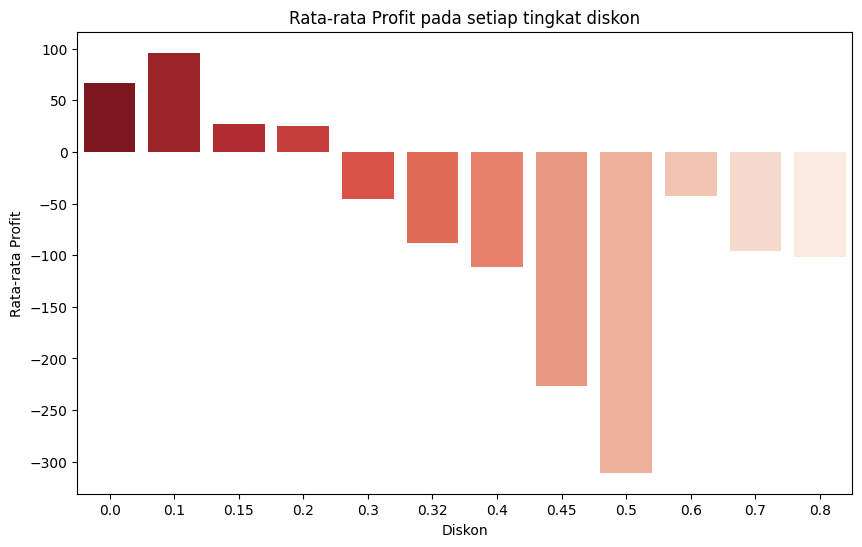

In [47]:
# Visualsasi tren rata-rata profit berdasarkan diskon
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Discount', y='Profit', errorbar=None, palette='Reds_r', estimator=np.mean)
plt.title('Rata-rata Profit pada setiap tingkat diskon')
plt.xlabel('Diskon')
plt.ylabel('Rata-rata Profit')
plt.show()

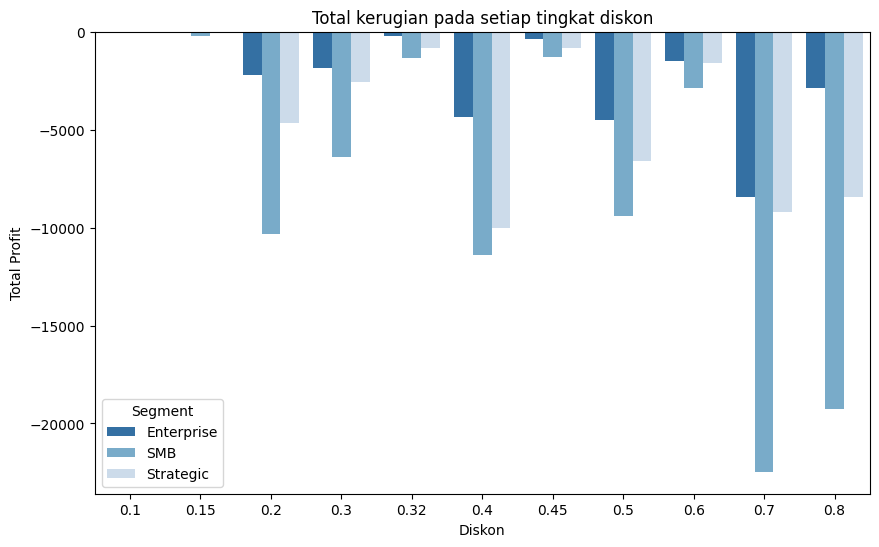

In [48]:
df_profitloss = df[df['Profit'] < 0]

plt.figure(figsize=(10, 6))
sns.barplot(data=df_profitloss, x='Discount', y='Profit', hue="Segment", errorbar=None, palette='Blues_r', estimator=np.sum)
plt.title('Total kerugian pada setiap tingkat diskon')
plt.xlabel('Diskon')
plt.ylabel('Total Profit')
plt.legend(title='Segment', loc='lower left')
plt.show()

Grafik di atas dengan jelas menunjukkan bahwa memberikan diskon tinggi (di atas 20% atau 0.2) berdampak masif pada kerugian, dengan segmen *SMB* (Small to Medium Businesses) seringkali menjadi penyumbang kerugian paling dalam (yang tertinggi melebihi -$20,000). 

Terakhir, sebagai *actionable insight*, kita akan melakukan *drill-down* untuk spesifik mengidentifikasi **5 produk dengan total kerugian paling parah** dari seluruh transaksi defisit (*profit_loss*). Daftar ini akan menjadi prioritas bagi manajemen dalam merevisi harga batas bawah (HPP) atau meniadakan diskon secara mutlak.

/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_1523/4231548650.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_product_loss, y='Product', x='Profit', palette='Reds_r')


<Figure size 1200x800 with 0 Axes>

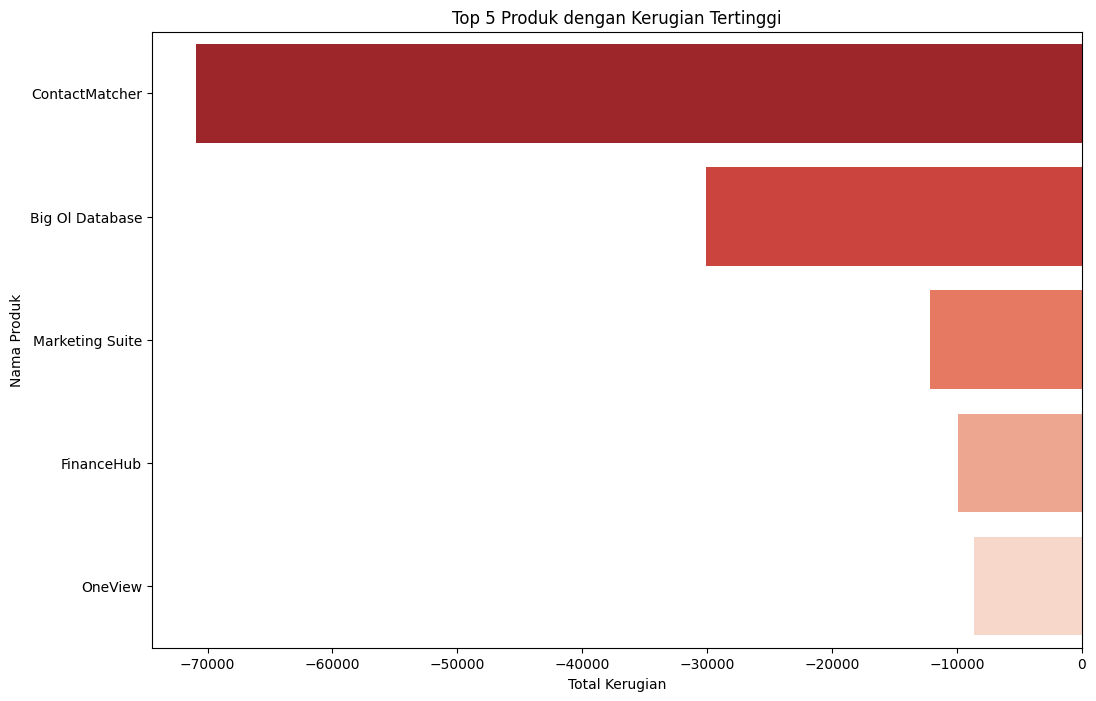

In [49]:
product_loss = df_profitloss.groupby('Product')['Profit'].sum().reset_index().sort_values(by='Profit')
plt.figure(figsize=(12, 8))
top_5_product_loss = product_loss.head(5)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_5_product_loss, y='Product', x='Profit', palette='Reds_r')
plt.title("Top 5 Produk dengan Kerugian Tertinggi")
plt.xlabel('Total Kerugian')
plt.ylabel('Nama Produk')
plt.show()

In [50]:
product_loss.head(5)

,Product,Profit
1,ContactMatcher,-70922.6447
0,Big Ol Database,-30118.6682
4,Marketing Suite,-12152.2060
3,FinanceHub,-9880.8413
6,OneView,-8629.6412


Setelah dianalisis, ternyata produk Contact Matcher memiliki total kerugian yang paling besar (< -$70,000), sedangkan produk yang lain memiliki kerugian setidaknya di atas -$40,000.

## Kesimpulan 

Dari analisis yang telah dilakukan, kita bisa membuat kesimpulan berikut tentang transaksi yang terjadi di Amazon:
* Dari keseluruhan data transaksi, terdapat **1.871 transaksi** yang mencatatkan kerugian (profit bernilai minus).
* Analisis korelasi membuktikan adanya hubungan negatif secara statistik antara besaran diskon dan profitabilitas; yang berarti semakin besar diskon yang diberikan, semakin anjlok keuntungan yang didapat perusahaan.
* Pemberian diskon mulai dari ambang batas **di atas 20% (0.2)** memicu penurunan rata-rata profit ke rasio negatif yang sangat ekstrem.

Karakteristik transaksi yang menjadi pemicu kerugian paling besar bagi perusahaan adalah sebagai berikut:
* Mayoritas total kerugian yang sangat dalam disumbang oleh **Segmen SMB (Small to Medium Businesses)**, terutama ketika segmen ini diberikan diskon besar di tingkat 40%, 50%, 70%, dan 80%.
* Kerugian terpusat secara signifikan pada beberapa lini produk tertentu yang sangat sensitif terhadap harga. Produk **Contact Matcher** menempati urutan teratas penyumbang kerugian terbesar (lebih dari -$70,000), disusul oleh produk-produk lain di jajaran *Top 5 Loss Products*.

## Rekomendasi
Sebagai masukan, kita menyarankan beberapa hal yang dapat diterapkan supaya kerugian dapat dibatasi:
1. **Menerapkan batas maksimal pemberian diskon di angka 20% secara berstandar.**
- Akan lebih baik apabila terdapat sistem persetujuan dari level Manajerial yang lebih tinggi bagi tim Sales apabila ada keharusan krusial untuk memberikan diskon melebihi 20%.
2. **Mengatur ulang strategi penjualan dan pemasaran khusus untuk Segmen SMB.**
- Hindari memaksakan *growth hacking* dengan cara membakar uang melalui potongan harga kasar di segmen SMB. Strategi bisa dialihkan ke program lain yang tidak memberatkan *profit*, seperti penambahan *Value-added Services* (bundling sistem, masa uji coba lebih lama, atau prioritas layanan).
3. **Melakukan pembekuan program diskon pada produk-produk yang rentan (*Top 5 Loss Products*).**
- Sangat disarankan untuk mengevaluasi ulang struktur biaya harian (HPP infrastruktur *SaaS*) dari produk tersebut, terutama pada produk Contact Matcher dan 4 produk rentan lainnya, atau pertimbangkan melakukan *re-pricing* (kenaikan harga dasar) untuk menyelamatkan kelayakan operasionalnya ke depan.

Dengan menerapkan strategi pembatasan diskon yang lebih ketat dan merevisi kembali penetapan harga pada segmen dan lini produk paling rentan, kita harap langkah ini bisa membantu perusahaan meminimalisir transaksi yang merugi, menyelamatkan margin, dan mendorong tingkat profitabilitas yang sehat secara keseluruhan di kuartal berikutnya.